In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import os
import glob
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

palette = {'cmGC': '#c04744', 'ncmGC': '#cfb406', 'NGS': '#3171ae', 'GC': '#c04744'}

In [2]:
data_source = '/Users/harryclark/Documents/data/xgboost_cell_number_assay/xgboost_cell_number_assay'
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master.csv'

if os.path.exists(save_path):
    data = pd.read_csv(save_path)
    print(f'Loaded master data: {data.shape}')
else:
    files = glob.glob(os.path.join(data_source, '*.csv'))
    dfs = []
    for i, f in enumerate(files):
        try:
            df_tmp = pd.read_csv(f)
            if not df_tmp.empty:
                dfs.append(df_tmp)
        except Exception as e:
            print(f'Skipped {os.path.basename(f)}: {e}')
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(files)} files read...')
    data = pd.concat(dfs, ignore_index=True)
    data.to_csv(save_path, index=False)
    print(f'Saved master data: {data.shape} -> {save_path}')

Skipped xgboost_cell_number_assay_extra_M27_D26_20_27.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M20_D20_100_107.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M20_D25_40_51.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M27_D20_20_23.csv: No columns to parse from file
  50/454 files read...
Skipped xgboost_cell_number_assay_extra_M29_D23_180_187.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M21_D16_240_253.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M25_D22_180_182.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M28_D17_80_85.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M26_D15_120_128.csv: No columns to parse from file
  100/454 files read...
Skipped xgboost_cell_number_assay_extra_M25_D21_60_78.csv: No columns to parse from file
Skipped xgboost_cell_number_assay_extra_M21_D15_240_2

In [3]:
# Filter to position baseline and rename columns to match original notebook conventions
data_pos = data[data['baseline'] == 'pos'].copy()
data_pos = data_pos.rename(columns={
    'target_cluster_id': 'cluster_id',
    'n_covariate_cells': 'n_neurons',
    'pR2_cv': 'pR2'
})

# Infer target cell type per cluster from which covariate_types appear for it.
# Clusters with cmGC covariate  -> target is cmGC
# Clusters with ncmGC covariate -> target is ncmGC
# Clusters with only GC/NGS     -> target is NGS
cluster_cov_types = (
    data_pos.groupby(['mouse', 'day', 'cluster_id'])['covariate_type']
    .apply(lambda x: set(x.unique()))
    .reset_index()
)

def infer_target_type(cov_set):
    if 'cmGC' in cov_set:
        return 'cmGC'
    elif 'ncmGC' in cov_set:
        return 'ncmGC'
    else:
        return 'NGS'

cluster_cov_types['target_type'] = cluster_cov_types['covariate_type'].apply(infer_target_type)
cluster_cov_types = cluster_cov_types[['mouse', 'day', 'cluster_id', 'target_type']]

data_pos = data_pos.merge(cluster_cov_types, on=['mouse', 'day', 'cluster_id'])

# tested_on = target cell type; trained_on = covariate_cell_type (GC or NGS)
data_pos['tested_on'] = data_pos['target_type']
data_pos['trained_on'] = data_pos['covariate_cell_type']

random_data = data_pos.copy()

# For the NGS covariate analysis, the cmGC/ncmGC distinction doesn't apply:
# co-modularity is defined relative to the *covariate* grid cells, so when the
# covariate is NGS the target is simply GC or NGS.
random_data_ngs = random_data.copy()
random_data_ngs.loc[random_data_ngs['tested_on'].isin(['cmGC', 'ncmGC']), 'tested_on'] = 'GC'

print(f'random_data shape: {random_data.shape}')
print(f"GC analysis  - trained_on='GC',  tested_on unique: {sorted(random_data[random_data['trained_on']=='GC']['tested_on'].unique())}")
print(f"NGS analysis - trained_on='NGS', tested_on unique: {sorted(random_data_ngs[random_data_ngs['trained_on']=='NGS']['tested_on'].unique())}")
print(f"n_neurons range: {random_data['n_neurons'].min()} - {random_data['n_neurons'].max()}")

random_data shape: (159746, 11)
GC analysis  - trained_on='GC',  tested_on unique: ['NGS', 'cmGC', 'ncmGC']
NGS analysis - trained_on='NGS', tested_on unique: ['GC', 'NGS']
n_neurons range: 0 - 10


In [4]:
def subset_by_n_neurons(df, trained_on='GC', n_neurons=5):
    """
    Subset to clusters that have at least n_neurons covariate cells available,
    returning only rows with n_neurons <= threshold.
    """
    df = df[df['trained_on'] == trained_on]
    df['mouse_day_cluster_id'] = (df['mouse'].astype(str) + '_' +
                                   df['day'].astype(str) + '_' +
                                   df['cluster_id'].astype(str))
    ids_with_enough = df[df['n_neurons'] >= n_neurons]['mouse_day_cluster_id'].unique()
    df = df[df['mouse_day_cluster_id'].isin(ids_with_enough)]
    return df[df['n_neurons'] <= n_neurons]

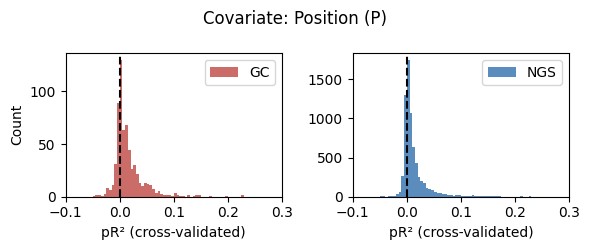

In [5]:
# Baseline pR2 distribution (n_neurons=0, position-only model)
random_data_baseline = (
    random_data[random_data['n_neurons'] == 0]
    .drop_duplicates(subset=['mouse', 'day', 'cluster_id'])
    .reset_index(drop=True)
)

gc_data  = random_data_baseline[random_data_baseline['tested_on'].isin(['cmGC', 'ncmGC'])]
ngs_data = random_data_baseline[random_data_baseline['tested_on'] == 'NGS']

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].hist(gc_data['pR2'],  bins=80, range=[-0.1, 0.3], alpha=0.8, color='#c04744', label='GC')
axes[0].set_xlabel('pR\u00b2 (cross-validated)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='k', linestyle='--')
axes[0].set_xlim([-0.1, 0.3])
axes[0].legend()

axes[1].hist(ngs_data['pR2'], bins=80, range=[-0.1, 0.3], alpha=0.8, color='#3171ae', label='NGS')
axes[1].set_xlabel('pR\u00b2 (cross-validated)')
axes[1].axvline(x=0, color='k', linestyle='--')
axes[1].set_xlim([-0.1, 0.3])
axes[1].legend()

plt.suptitle('Covariate: Position (P)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_Position_covariate.pdf', dpi=300)
plt.show()

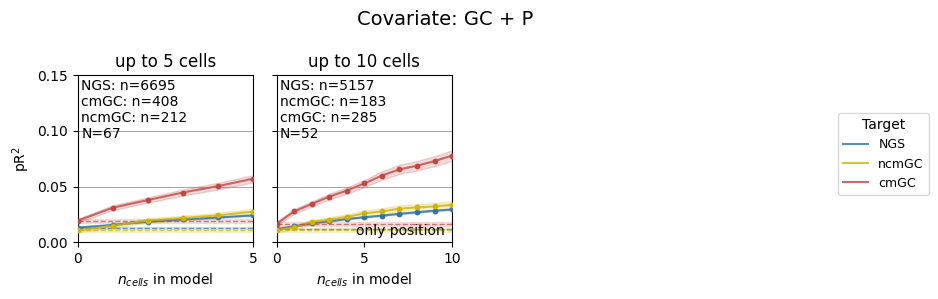

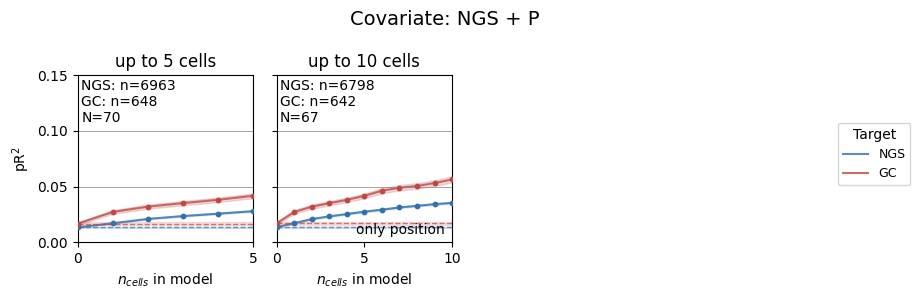

In [6]:
figsize = (9, 3)

def plot_ncells_panel(df, trained_on, ncells_list, suptitle, save_name):
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)
    last_valid = len(ncells_list) - 1
    for i in range(4):
        if i < len(ncells_list):
            max_n = ncells_list[i]
            ax = axes[i]
            valid_data = subset_by_n_neurons(df, n_neurons=max_n, trained_on=trained_on)
            if valid_data.empty:
                ax.axis('off')
                continue
            annotation_lines = []
            y0_list = []
            for tested_on in valid_data['tested_on'].unique():
                df_plot = valid_data[
                    (valid_data['trained_on'] == trained_on) &
                    (valid_data['tested_on'] == tested_on)
                ]
                if df_plot.empty:
                    continue
                pivot = df_plot.pivot_table(
                    index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2'
                ).sort_index(axis=1)
                mean = pivot.mean(axis=0)
                sem  = pivot.sem(axis=0)
                color = palette.get(tested_on)
                mean = mean[mean.index <= max_n]
                sem  = sem[sem.index   <= max_n]
                ax.plot(mean.index, mean.values, label=tested_on, alpha=0.8, color=color)
                ax.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
                ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
                if 0 in pivot.columns:
                    y0, y0_sem = mean.loc[0], sem.loc[0]
                    y0_list.append(y0)
                    ax.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
                    ax.fill_between([0, max_n], y0 - y0_sem, y0 + y0_sem,
                                    color=color, alpha=0.15, zorder=2)
                n_test_cells = len(df_plot[df_plot['n_neurons'] == 1])
                annotation_lines.append(f'{tested_on}: n={n_test_cells}')
            n_sessions = valid_data[['mouse', 'day']].drop_duplicates().shape[0]
            annotation_lines.append(f'N={n_sessions}')
            ax.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top',
                    transform=ax.transAxes, fontsize=10, color='k')
            for yref in [0.05, 0.1, 0.15]:
                ax.axhline(yref, linestyle='solid', color='grey', linewidth=0.5)
            ax.set_xlim(0, max_n)
            ax.set_ylim(0, 0.15)
            ax.set_xticks([0, 5] if i == 0 else [0, max_n // 2, max_n])
            ax.set_yticks([0, 0.05, 0.1, 0.15])
            ax.set_xlabel('$n_{cells}$ in model')
            if i == 0:
                ax.set_ylabel('pR$^2$')
            ax.set_title(f'up to {max_n} cells')
            if i == last_valid and y0_list:
                ax.annotate('only position', xy=(max_n, max(y0_list)), xycoords='data',
                            xytext=(-5, -10), textcoords='offset points',
                            ha='right', va='bottom', fontsize=10, color='k')
        else:
            axes[i].axis('off')
    ref_ax = axes[last_valid]
    handles, labels = ref_ax.get_legend_handles_labels()
    fig.legend(handles, labels, title='Target', fontsize=9, loc='center left', bbox_to_anchor=(0.93, 0.5))
    fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6, right=0.95)
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()

# GC covariate: targets split into cmGC / ncmGC / NGS
plot_ncells_panel(
    random_data, 'GC', [5, 10],
    'Covariate: GC + P',
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_xgboost_added_pR2_gc_4col.pdf'
)

# NGS covariate: targets split into GC / NGS only
plot_ncells_panel(
    random_data_ngs, 'NGS', [5, 10],
    'Covariate: NGS + P',
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_xgboost_added_pR2_ngs_4col.pdf'
)

In [7]:
import statsmodels.formula.api as smf

# GC covariate LMM  (targets: cmGC, ncmGC, NGS)
gc_lmm_data = random_data[random_data['trained_on'] == 'GC'].copy()
gc_lmm_data['mouse_day'] = gc_lmm_data['mouse'].astype(str) + '_' + gc_lmm_data['day'].astype(str)
model = smf.mixedlm('pR2 ~ tested_on * n_neurons', gc_lmm_data,
                    groups='mouse', re_formula='~1', vc_formula={'day': '0 + C(day)'})
print('Results for trained_on GC:')
print(model.fit().summary())

# NGS covariate LMM  (targets: GC, NGS)
ngs_lmm_data = random_data_ngs[random_data_ngs['trained_on'] == 'NGS'].copy()
ngs_lmm_data['mouse_day'] = ngs_lmm_data['mouse'].astype(str) + '_' + ngs_lmm_data['day'].astype(str)
model = smf.mixedlm('pR2 ~ tested_on * n_neurons', ngs_lmm_data,
                    groups='mouse', re_formula='~1', vc_formula={'day': '0 + C(day)'})
print('Results for trained_on NGS:')
print(model.fit().summary())

Results for trained_on GC:
                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     pR2        
No. Observations:       76457       Method:                 REML       
No. Groups:             8           Scale:                  0.0011     
Min. group size:        3540        Log-Likelihood:         150423.7474
Max. group size:        22739       Converged:              Yes        
Mean group size:        9557.1                                         
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     0.026    0.008  3.250 0.001  0.010  0.042
tested_on[T.cmGC]            -0.001    0.001 -1.236 0.217 -0.003  0.001
tested_on[T.ncmGC]           -0.003    0.001 -2.454 0.014 -0.006 -0.001
n_neurons                     0.002    0.000 42.548 0.

to compare pR2 across tested_on cell_types, we can cycle through the tested_on groups, making each one the reference group from which to compare the other groups against.

In [8]:
import statsmodels.formula.api as smf
import pandas as pd

all_results_by_trained = {}

lmm_datasets = {
    'GC':  random_data[random_data['trained_on'] == 'GC'].copy(),
    'NGS': random_data_ngs[random_data_ngs['trained_on'] == 'NGS'].copy(),
}

for trained_on, data_to_use in lmm_datasets.items():
    tested_on_groups = data_to_use['tested_on'].unique()
    results = []
    for ref in tested_on_groups:
        data_to_use['tested_on'] = pd.Categorical(
            data_to_use['tested_on'],
            categories=[ref] + [g for g in tested_on_groups if g != ref],
            ordered=True
        )
        model = smf.mixedlm(
            'pR2 ~ tested_on * n_neurons', data_to_use,
            groups='mouse', re_formula='~1', vc_formula={'day': '0 + C(day)'}
        )
        result = model.fit()
        summary_df = pd.DataFrame({
            'coef':      result.params,
            'ci_lower':  result.conf_int()[0],
            'ci_upper':  result.conf_int()[1],
            'pval':      result.pvalues,
            'reference': ref
        })
        results.append(summary_df.reset_index().rename(columns={'index': 'term'}))
    all_results = pd.concat(results, ignore_index=True)
    all_results_by_trained[trained_on] = all_results
    print(f'\n=== trained_on = {trained_on} ===')
    display(all_results)


=== trained_on = GC ===


,term,coef,ci_lower,ci_upper,pval,reference
0,Intercept,0.026104,0.010359,0.041848,1.155821e-03,NGS
1,tested_on[T.cmGC],-0.001227,-0.003172,0.000719,2.165747e-01,NGS
2,tested_on[T.ncmGC],-0.003232,-0.005813,-0.000651,1.412364e-02,NGS
3,n_neurons,0.001800,0.001717,0.001882,0.000000e+00,NGS
4,tested_on[T.cmGC]:n_neurons,0.004219,0.003875,0.004563,5.820870e-128,NGS
5,tested_on[T.ncmGC]:n_neurons,0.000652,0.000203,0.001100,4.392027e-03,NGS
6,mouse Var,0.401994,-0.084416,0.888404,1.052726e-01,NGS
7,day Var,0.442497,0.286749,0.598245,2.569767e-08,NGS
8,Intercept,0.024877,0.009027,0.040727,2.096115e-03,cmGC
9,tested_on[T.NGS],0.001227,-0.000719,0.003172,2.165747e-01,cmGC



=== trained_on = NGS ===


,term,coef,ci_lower,ci_upper,pval,reference
0,Intercept,0.030773,0.011371,0.050175,1.879074e-03,NGS
1,tested_on[T.GC],-0.009406,-0.011191,-0.007621,5.300446e-25,NGS
2,n_neurons,0.002193,0.002106,0.002280,0.000000e+00,NGS
3,tested_on[T.GC]:n_neurons,0.001521,0.001224,0.001818,9.520608e-24,NGS
4,mouse Var,0.464855,-0.086332,1.016043,9.833589e-02,NGS
5,day Var,0.524851,0.341088,0.708614,2.169448e-08,NGS
6,Intercept,0.021367,0.001898,0.040836,3.147275e-02,GC
7,tested_on[T.NGS],0.009406,0.007621,0.011191,5.300445e-25,GC
8,n_neurons,0.003714,0.003430,0.003998,3.993679e-145,GC
9,tested_on[T.NGS]:n_neurons,-0.001521,-0.001818,-0.001224,9.520608e-24,GC


In [9]:
for trained_on, all_results in all_results_by_trained.items():
    main_effects = all_results[all_results['term'].str.startswith('tested_on[')].copy()
    interactions = all_results[
        all_results['term'].str.startswith('tested_on[') &
        all_results['term'].str.contains(':n_neurons')
    ].copy()
    main_effects['compared_to'] = main_effects['term'].str.extract(r'tested_on\[(.+?)\]')
    main_effects['effect_type'] = 'main'
    interactions['compared_to'] = interactions['term'].str.extract(r'tested_on\[(.+?)\]:n_neurons')
    interactions['effect_type'] = 'interaction'
    summary = pd.concat([main_effects, interactions], ignore_index=True)
    summary = summary[['reference', 'compared_to', 'effect_type', 'coef', 'ci_lower', 'ci_upper', 'pval']]
    summary = summary.sort_values(['reference', 'effect_type', 'compared_to'])
    print(f'\n=== trained_on = {trained_on} ===')
    display(summary)


=== trained_on = GC ===


,reference,compared_to,effect_type,coef,ci_lower,ci_upper,pval
12,NGS,T.cmGC,interaction,0.004219,0.003875,0.004563,5.820870e-128
13,NGS,T.ncmGC,interaction,0.000652,0.000203,0.001100,4.392027e-03
0,NGS,T.cmGC,main,-0.001227,-0.003172,0.000719,2.165747e-01
2,NGS,T.cmGC,main,0.004219,0.003875,0.004563,5.820870e-128
1,NGS,T.ncmGC,main,-0.003232,-0.005813,-0.000651,1.412364e-02
3,NGS,T.ncmGC,main,0.000652,0.000203,0.001100,4.392027e-03
14,cmGC,T.NGS,interaction,-0.004219,-0.004563,-0.003875,5.820870e-128
15,cmGC,T.ncmGC,interaction,-0.003567,-0.004120,-0.003014,1.222510e-36
4,cmGC,T.NGS,main,0.001227,-0.000719,0.003172,2.165747e-01
6,cmGC,T.NGS,main,-0.004219,-0.004563,-0.003875,5.820870e-128



=== trained_on = NGS ===


,reference,compared_to,effect_type,coef,ci_lower,ci_upper,pval
5,GC,T.NGS,interaction,-0.001521,-0.001818,-0.001224,9.520608e-24
2,GC,T.NGS,main,0.009406,0.007621,0.011191,5.300445e-25
3,GC,T.NGS,main,-0.001521,-0.001818,-0.001224,9.520608e-24
4,NGS,T.GC,interaction,0.001521,0.001224,0.001818,9.520608e-24
0,NGS,T.GC,main,-0.009406,-0.011191,-0.007621,5.300446e-25
1,NGS,T.GC,main,0.001521,0.001224,0.001818,9.520608e-24


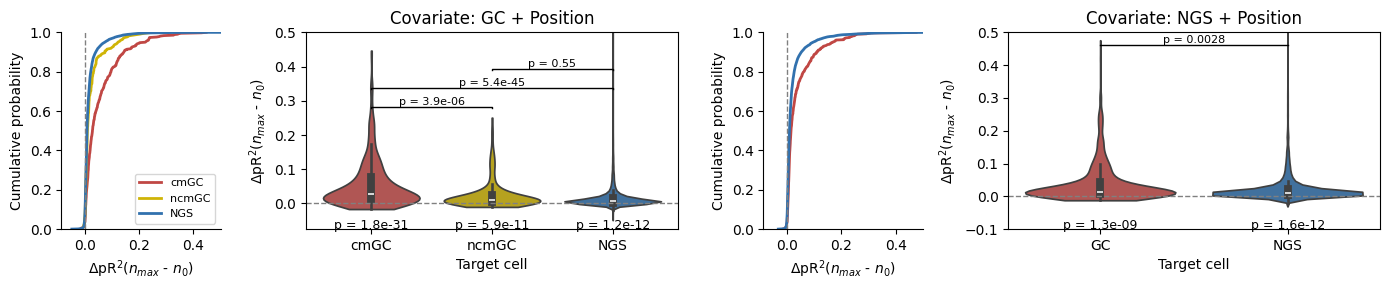

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

vc = {'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'}

def compute_added_pR2_max(df, trained_on, tested_on_groups):
    records = []
    for tested_on in tested_on_groups:
        df_plot = df[
            (df['trained_on'] == trained_on) &
            (df['tested_on'] == tested_on) &
            df['n_neurons'].notna()
        ].copy()
        pivot = df_plot.pivot_table(
            index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2'
        )
        for idx, row in pivot.dropna(subset=[0]).iterrows():
            nonzero = [c for c in row.index if c != 0 and not pd.isna(row[c])]
            if not nonzero:
                continue
            max_n = max(nonzero)
            records.append({'added_pR2': row[max_n] - row[0], 'tested_on': tested_on,
                            'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2],
                            'max_n_neurons': max_n})
    return pd.DataFrame(records)

def pairwise_lmm(df, groups):
    pvals = {}
    pairs = [(g1, g2) for i, g1 in enumerate(groups) for g2 in groups[i+1:]]
    for g1, g2 in pairs:
        temp = df[df['tested_on'].isin([g1, g2])].copy()
        temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
        result = smf.mixedlm('added_pR2 ~ tested_on', temp,
                              groups=temp['mouse'], vc_formula=vc).fit()
        pvals[(g1, g2)] = result.pvalues.get(f'tested_on[T.{g2}]', np.nan)
    return pvals

def zero_pvals_lmm(df, groups):
    zero_pvals = {}
    for ref in groups:
        temp = df.copy()
        temp['tested_on'] = pd.Categorical(
            temp['tested_on'],
            categories=[ref] + [g for g in groups if g != ref],
            ordered=True
        )
        result = smf.mixedlm('added_pR2 ~ tested_on', temp,
                              groups=temp['mouse'], vc_formula=vc).fit()
        zero_pvals[ref] = result.pvalues['Intercept']
    return zero_pvals

def add_significance_bars(ax, groups, pvals, y_start, step):
    for idx, ((g1, g2), pval) in enumerate(pvals.items()):
        x1, x2 = groups.index(g1), groups.index(g2)
        y = y_start + idx * step
        ax.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
        ax.text((x1 + x2) / 2, y + 0.002, f'p = {pval:.2g}',
                ha='center', va='bottom', fontsize=8)

# GC covariate: targets cmGC / ncmGC / NGS
gc_groups = ['cmGC', 'ncmGC', 'NGS']
added_pR2_gc_max = compute_added_pR2_max(random_data, 'GC', gc_groups)
pvals_gc      = pairwise_lmm(added_pR2_gc_max, gc_groups)
gc_zero_pvals = zero_pvals_lmm(added_pR2_gc_max, gc_groups)

# NGS covariate: targets GC / NGS
ngs_groups = ['GC', 'NGS']
added_pR2_ngs_max = compute_added_pR2_max(random_data_ngs, 'NGS', ngs_groups)
pvals_ngs      = pairwise_lmm(added_pR2_ngs_max, ngs_groups)
ngs_zero_pvals = zero_pvals_lmm(added_pR2_ngs_max, ngs_groups)

fig, axes = plt.subplots(1, 4, figsize=(14, 3), width_ratios=[0.3, 0.7, 0.3, 0.7])

# GC CDF
ax = axes[0]
for group in gc_groups:
    vals = added_pR2_gc_max[added_pR2_gc_max['tested_on'] == group]['added_pR2'].dropna()
    sv = np.sort(vals)
    ax.plot(sv, np.arange(1, len(sv)+1) / len(sv), color=palette[group], lw=2, label=group)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax.set_ylabel('Cumulative probability')
ax.set_xlim(None, 0.5); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=8)

# GC Violin
ax = axes[1]
sns.violinplot(x='tested_on', y='added_pR2', data=added_pR2_gc_max,
               inner='box', cut=0, palette=palette, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax.set_xlabel('Target cell')
ax.set_title('Covariate: GC + Position')
ax.set_ylim(-0.075, 0.5)
add_significance_bars(ax, gc_groups, pvals_gc, y_start=0.28, step=0.055)
y_bottom = ax.get_ylim()[0] + 0.03
for i, group in enumerate(gc_groups):
    ax.text(i, y_bottom, f'p = {gc_zero_pvals[group]:.2g}', ha='center', va='top', fontsize=9)

# NGS CDF
ax = axes[2]
for group in ngs_groups:
    vals = added_pR2_ngs_max[added_pR2_ngs_max['tested_on'] == group]['added_pR2'].dropna()
    sv = np.sort(vals)
    ax.plot(sv, np.arange(1, len(sv)+1) / len(sv), color=palette[group], lw=2)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax.set_ylabel('Cumulative probability')
ax.set_xlim(None, 0.5); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# NGS Violin
ax = axes[3]
sns.violinplot(x='tested_on', y='added_pR2', data=added_pR2_ngs_max,
               inner='box', cut=0, palette=palette, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax.set_xlabel('Target cell')
ax.set_title('Covariate: NGS + Position')
ax.set_ylim(-0.1, 0.5)
add_significance_bars(ax, ngs_groups, pvals_ngs, y_start=0.46, step=0.03)
y_bottom = ax.get_ylim()[0] + 0.03
for i, group in enumerate(ngs_groups):
    ax.text(i, y_bottom, f'p = {ngs_zero_pvals[group]:.2g}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_xgboost_added_pR2_max_gc_ngs_combined_4col_lmm.pdf',
    bbox_inches='tight'
)
plt.show()

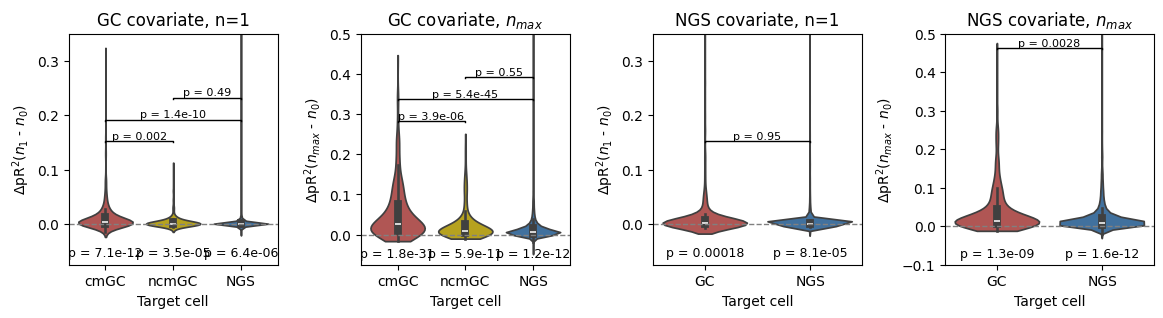

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

def compute_added_pR2_n1(df, trained_on, tested_on_groups):
    records = []
    for tested_on in tested_on_groups:
        df_plot = df[
            (df['trained_on'] == trained_on) &
            (df['tested_on'] == tested_on) &
            df['n_neurons'].isin([0, 1])
        ].copy()
        pivot = df_plot.pivot_table(
            index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2'
        ).dropna(subset=[0, 1])
        for (m, d, c), row in pivot.iterrows():
            records.append({'added_pR2': row[1] - row[0], 'tested_on': tested_on,
                            'mouse': m, 'day': d, 'cluster_id': c})
    return pd.DataFrame(records)

# GC covariate: targets cmGC / ncmGC / NGS
gc_groups = ['cmGC', 'ncmGC', 'NGS']
added_pR2_gc  = compute_added_pR2_n1(random_data, 'GC', gc_groups)
pvals_gc_n1   = pairwise_lmm(added_pR2_gc, gc_groups)
gc_zero_n1    = zero_pvals_lmm(added_pR2_gc, gc_groups)

# NGS covariate: targets GC / NGS
ngs_groups = ['GC', 'NGS']
added_pR2_ngs = compute_added_pR2_n1(random_data_ngs, 'NGS', ngs_groups)
pvals_ngs_n1  = pairwise_lmm(added_pR2_ngs, ngs_groups)
ngs_zero_n1   = zero_pvals_lmm(added_pR2_ngs, ngs_groups)

def violin_panel(ax, df, groups, pvals, zero_pvals, ylabel, title,
                 ylim=(-0.075, 0.35), y_sig_start=0.15, y_sig_step=0.04):
    sns.violinplot(x='tested_on', y='added_pR2', data=df,
                   inner='box', cut=0, palette=palette, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Target cell')
    ax.set_title(title)
    ax.set_ylim(*ylim)
    add_significance_bars(ax, groups, pvals, y_start=y_sig_start, step=y_sig_step)
    y_bottom = ylim[0] + 0.01
    for i, group in enumerate(groups):
        ax.text(i, y_bottom, f'p = {zero_pvals[group]:.2g}',
                ha='center', va='bottom', fontsize=9)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

violin_panel(axes[0], added_pR2_gc, gc_groups, pvals_gc_n1, gc_zero_n1,
             '$\\Delta$pR$^2$($n_1$ - $n_0$)', 'GC covariate, n=1',
             ylim=(-0.075, 0.35), y_sig_start=0.15, y_sig_step=0.04)

violin_panel(axes[1], added_pR2_gc_max, gc_groups, pvals_gc, gc_zero_pvals,
             '$\\Delta$pR$^2$($n_{max}$ - $n_0$)', 'GC covariate, $n_{max}$',
             ylim=(-0.075, 0.5), y_sig_start=0.28, y_sig_step=0.055)

violin_panel(axes[2], added_pR2_ngs, ngs_groups, pvals_ngs_n1, ngs_zero_n1,
             '$\\Delta$pR$^2$($n_1$ - $n_0$)', 'NGS covariate, n=1',
             ylim=(-0.075, 0.35), y_sig_start=0.15, y_sig_step=0.04)

violin_panel(axes[3], added_pR2_ngs_max, ngs_groups, pvals_ngs, ngs_zero_pvals,
             '$\\Delta$pR$^2$($n_{max}$ - $n_0$)', 'NGS covariate, $n_{max}$',
             ylim=(-0.1, 0.5), y_sig_start=0.46, y_sig_step=0.03)

plt.subplots_adjust(wspace=0.4)
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_xgboost_added_pR2_gc_ngs_violin_only_4col.pdf',
    bbox_inches='tight'
)
plt.show()

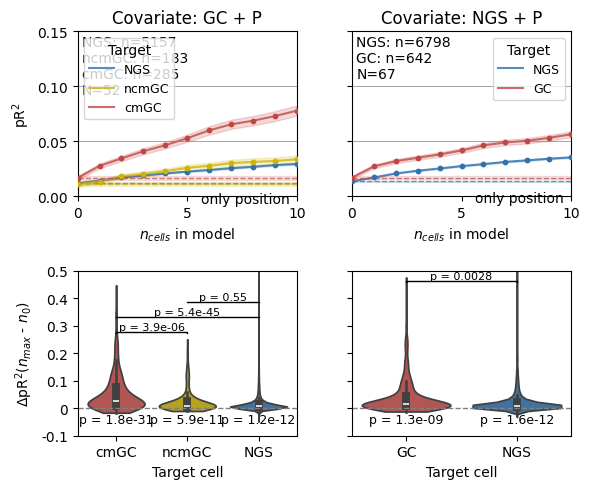

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

max_n = 10
gc_groups  = ['cmGC', 'ncmGC', 'NGS']
ngs_groups = ['GC', 'NGS']

fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharey='row')

def line_panel(ax, df, trained_on, max_n, ylabel=False):
    valid_data = subset_by_n_neurons(df, n_neurons=max_n, trained_on=trained_on)
    if valid_data.empty:
        ax.axis('off')
        return
    annotation_lines = []
    y0_list = []
    for tested_on in valid_data['tested_on'].unique():
        df_plot = valid_data[
            (valid_data['trained_on'] == trained_on) &
            (valid_data['tested_on'] == tested_on)
        ]
        if df_plot.empty:
            continue
        pivot = df_plot.pivot_table(
            index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2'
        ).sort_index(axis=1)
        mean = pivot.mean(axis=0)
        sem  = pivot.sem(axis=0)
        color = palette.get(tested_on)
        mean = mean[mean.index <= max_n]
        sem  = sem[sem.index   <= max_n]
        ax.plot(mean.index, mean.values, label=tested_on, alpha=0.8, color=color)
        ax.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
        ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
        if 0 in pivot.columns:
            y0, y0_sem = mean.loc[0], sem.loc[0]
            y0_list.append(y0)
            ax.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
            ax.fill_between([0, max_n], y0 - y0_sem, y0 + y0_sem,
                            color=color, alpha=0.15, zorder=2)
        annotation_lines.append(f'{tested_on}: n={len(df_plot[df_plot["n_neurons"] == 1])}')
    annotation_lines.append(f'N={valid_data[["mouse", "day"]].drop_duplicates().shape[0]}')
    ax.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top',
            transform=ax.transAxes, fontsize=10, color='k')
    for yref in [0.05, 0.1, 0.15]:
        ax.axhline(yref, linestyle='solid', color='grey', linewidth=0.5)
    ax.set_xlim(0, max_n)
    ax.set_ylim(0, 0.15)
    ax.set_xticks([0, 5, 10])
    ax.set_yticks([0, 0.05, 0.1, 0.15])
    ax.set_xlabel('$n_{cells}$ in model')
    if ylabel:
        ax.set_ylabel('pR$^2$')
    ax.legend(title='Target', fontsize=9)
    if y0_list:
        ax.annotate('only position', xy=(max_n, max(y0_list)), xycoords='data',
                    xytext=(-5, -20), textcoords='offset points',
                    ha='right', va='bottom', fontsize=10, color='k')

# Top row: line plots
line_panel(axes[0, 0], random_data,     'GC',  max_n, ylabel=True)
axes[0, 0].set_title('Covariate: GC + P')
line_panel(axes[0, 1], random_data_ngs, 'NGS', max_n)
axes[0, 1].set_title('Covariate: NGS + P')

# Bottom row: violin plots (max n)
def violin_bottom(ax, df, groups, pvals, zero_pvals, ylim=(-0.075, 0.5),
                  y_sig_start=0.275, y_sig_step=0.055):
    sns.violinplot(x='tested_on', y='added_pR2', data=df,
                   inner='box', cut=0, palette=palette, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
    ax.set_xlabel('Target cell')
    ax.set_title('')
    ax.set_ylim(*ylim)
    ax.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticklabels(['-0.1', '0', '0.1', '0.2', '0.3', '0.4', '0.5'])
    add_significance_bars(ax, groups, pvals, y_start=y_sig_start, step=y_sig_step)
    y_bottom = ylim[0] + 0.01
    for i, group in enumerate(groups):
        ax.text(i, y_bottom, f'p = {zero_pvals[group]:.2g}',
                ha='center', va='bottom', fontsize=9)

violin_bottom(axes[1, 0], added_pR2_gc_max,  gc_groups,  pvals_gc,  gc_zero_pvals)
violin_bottom(axes[1, 1], added_pR2_ngs_max, ngs_groups, pvals_ngs, ngs_zero_pvals,
              y_sig_start=0.46, y_sig_step=0.03)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.45)
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/v2_xgboost_added_pR2_gc_ngs_combined_line_violin_grid.pdf',
    bbox_inches='tight'
)
plt.show()